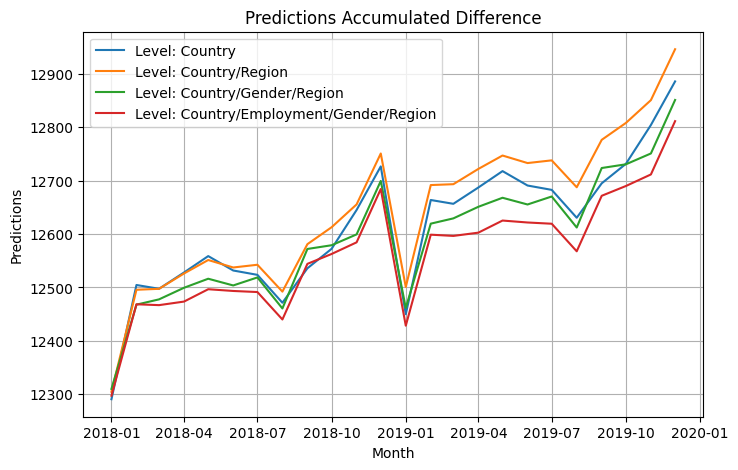

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

from statsforecast.core import StatsForecast
from statsforecast.models import AutoETS
from datasetsforecast.hierarchical import HierarchicalData
from hierarchicalforecast.utils import HierarchicalPlot

Y_df, S, tags = HierarchicalData.load('./data', 'Labour')
Y_df['ds'] = pd.to_datetime(Y_df['ds'])
S = S.reset_index(names="unique_id")

Y_test_df  = Y_df.groupby('unique_id').tail(24)
Y_train_df = Y_df.drop(Y_test_df.index)

fcst = StatsForecast(
    models=[AutoETS(season_length=12, model='AAZ')],
    freq='MS',
    n_jobs=-1
)
Y_hat_df = fcst.forecast(df=Y_train_df, h=24).reset_index()

# Plot prediction difference of different aggregation
# Levels Country, Country/Region, Country/Gender/Region ...
hplots = HierarchicalPlot(S=S, tags=tags)

hplots.plot_hierarchical_predictions_gap(
    Y_df=Y_hat_df, models='AutoETS',
    xlabel='Month', ylabel='Predictions',
)

plt.show()

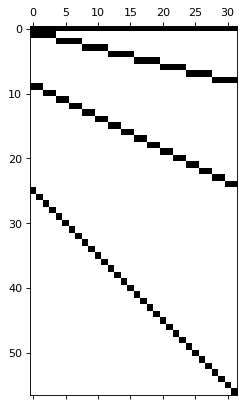

In [13]:
hplots.plot_summing_matrix()

plt.show()

In [11]:
Y_hat_df.unique_id.unique()

array(["['Australian Capital Territory']",
       "['Employed full-time', 'Females', 'Australian Capital Territory']",
       "['Employed full-time', 'Females', 'New South Wales']",
       "['Employed full-time', 'Females', 'Northern Territory']",
       "['Employed full-time', 'Females', 'Queensland']",
       "['Employed full-time', 'Females', 'South Australia']",
       "['Employed full-time', 'Females', 'Tasmania']",
       "['Employed full-time', 'Females', 'Victoria']",
       "['Employed full-time', 'Females', 'Western Australia']",
       "['Employed full-time', 'Males', 'Australian Capital Territory']",
       "['Employed full-time', 'Males', 'New South Wales']",
       "['Employed full-time', 'Males', 'Northern Territory']",
       "['Employed full-time', 'Males', 'Queensland']",
       "['Employed full-time', 'Males', 'South Australia']",
       "['Employed full-time', 'Males', 'Tasmania']",
       "['Employed full-time', 'Males', 'Victoria']",
       "['Employed full-time',

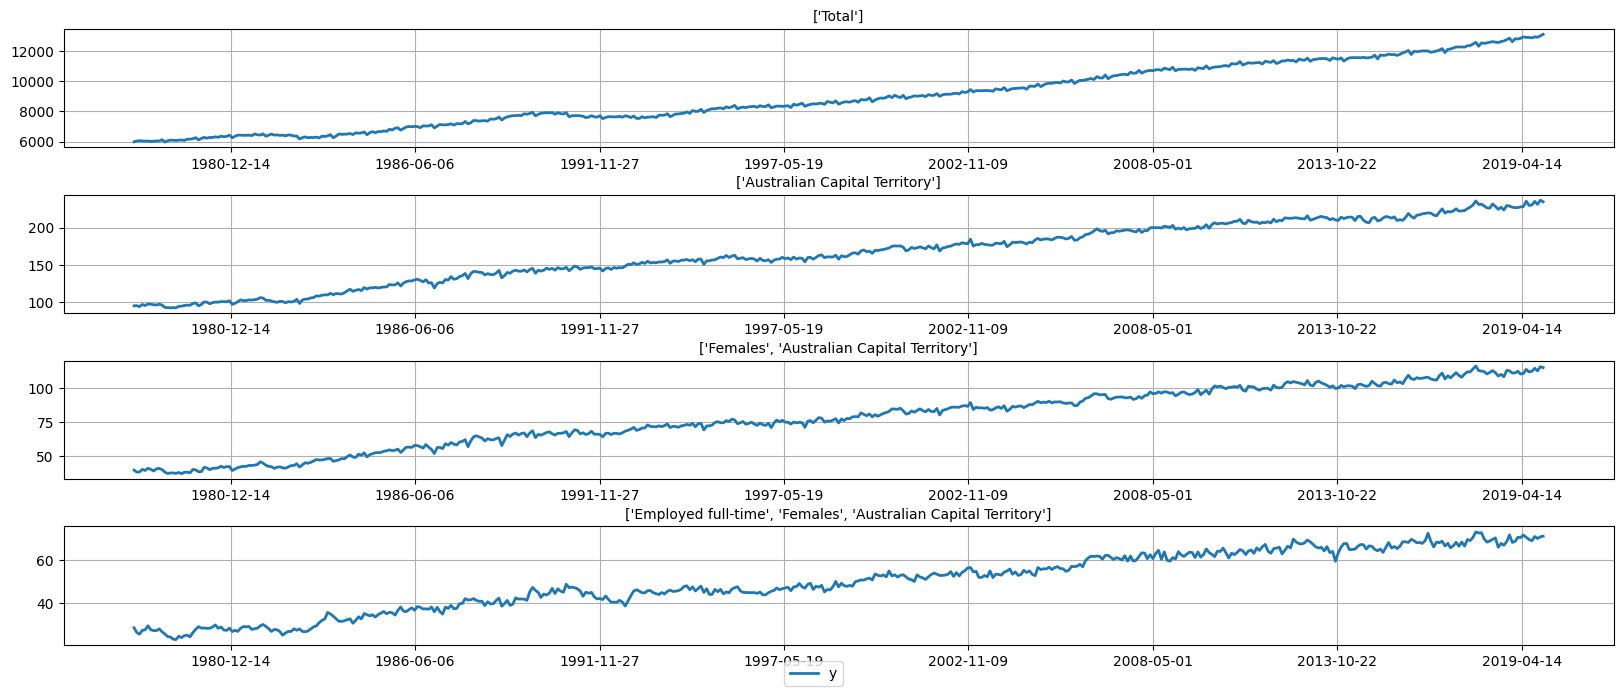

In [14]:
hplots.plot_hierarchically_linked_series(
    bottom_series="['Employed full-time', 'Females', 'Australian Capital Territory']",  # <-- Add this required parameter
    Y_df=Y_df,
)
plt.show()